# TwoStageSignalAgent Lambda-Tau Analysis

This notebook summarizes the simplified two-stage model fit where only two parameters are fit:

\[
\lambda,\tau
\]

Fixed parameters:

\[
\beta=3.0,\quad k=10,\quad \alpha=1.0,\quad \eta=1.0
\]

The model continuously blends early flexible joint-RL and late committed signaling:

\[
\rho_t=\sigma(k(C_t-\tau))
\]

\[
\pi(a)=(1-\rho_t)\pi_{early}(a)+\rho_t\pi_{late}(a)
\]

The main fit target is trial/player-level human-human commitment and signaling across 2P3G distance conditions.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

PROJECT_ROOT = Path.cwd()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / 'client').exists() and (candidate / 'dataAnalysis').exists():
        PROJECT_ROOT = candidate
        break
OUT = PROJECT_ROOT / 'dataAnalysis' / 'model_model' / 'two_stage_signal_agent' / 'outputs' / 'two_stage_signal_lambda_tau_fit_alpha1_eta1'
RAW = PROJECT_ROOT / 'dataAnalysis' / 'raw_data' / 'model_model_simulations' / 'two_stage_signal_agent' / 'lambda_tau_alpha1_eta1'

summary = json.loads((OUT / 'two_stage_signal_4param_fit_summary.json').read_text())
grid = pd.read_csv(OUT / 'two_stage_signal_4param_grid.csv')
best_metrics = pd.read_csv(OUT / 'two_stage_signal_4param_best_metrics.csv')
human_targets = pd.read_csv(OUT / 'human_trial_level_commitment_signaling_targets.csv')

best = summary['best_by_total_nll']
print('Output directory:', OUT)
print('Grid rows:', len(grid))
print('Best parameters:', {k: best[k] for k in ['lambda', 'tau', 'alpha', 'eta']})
print('NLL:', {k: round(best[k], 3) for k in ['total_nll', 'commitment_nll', 'signaling_nll']})

Output directory: /Users/chengshaozhe/Documents/DukeECClab/code/multiplePlayerGridGame_socketIO/dataAnalysis/model_model/two_stage_signal_agent/outputs/two_stage_signal_lambda_tau_fit_alpha1_eta1
Grid rows: 63
Best parameters: {'lambda': 0.15, 'tau': 0.7, 'alpha': 1.0, 'eta': 1.0}
NLL: {'total_nll': 364.453, 'commitment_nll': 178.653, 'signaling_nll': 185.8}


## Best Fit

The best fixed-\(\alpha\), fixed-\(\eta\) fit selects:

\[
\lambda=0.15,\quad \tau=0.70
\]

In [2]:
cols = [
    'lambda', 'tau', 'alpha', 'eta',
    'average_success_percent', 'average_efficiency_percent', 'average_commitment_percent', 'average_signaling_percent',
    'equal_success_percent', 'equal_efficiency_percent', 'equal_commitment_percent', 'equal_signaling_percent',
]
display(best_metrics[cols].round(2))

,lambda,tau,alpha,eta,average_success_percent,average_efficiency_percent,average_commitment_percent,average_signaling_percent,equal_success_percent,equal_efficiency_percent,equal_commitment_percent,equal_signaling_percent
0,0.15,0.7,1.0,1.0,96.67,88.73,67.94,40.54,100.0,97.5,79.44,55.0


## Human Targets

The fit uses human-human trial/player-level commitment and signaling by distance condition.

In [3]:
display(human_targets.assign(human_rate_percent=(human_targets['human_rate'] * 100).round(1)))

,distanceCondition,metric,human_n,human_k,human_rate,human_rate_percent
0,closer_to_player1,commitment,96,53,0.552083,55.2
1,closer_to_player1,signalingMove,83,42,0.506024,50.6
2,equal_to_both,commitment,94,79,0.840426,84.0
3,equal_to_both,signalingMove,94,55,0.585106,58.5
4,closer_to_player2,commitment,94,53,0.563830,56.4
5,closer_to_player2,signalingMove,84,38,0.452381,45.2


## Lambda-Tau Grid: Four Measures

Each heatmap cell is one model-model simulation setting with 30 sessions × 12 2P3G trials/session.

### Average across all 2P3G distance conditions

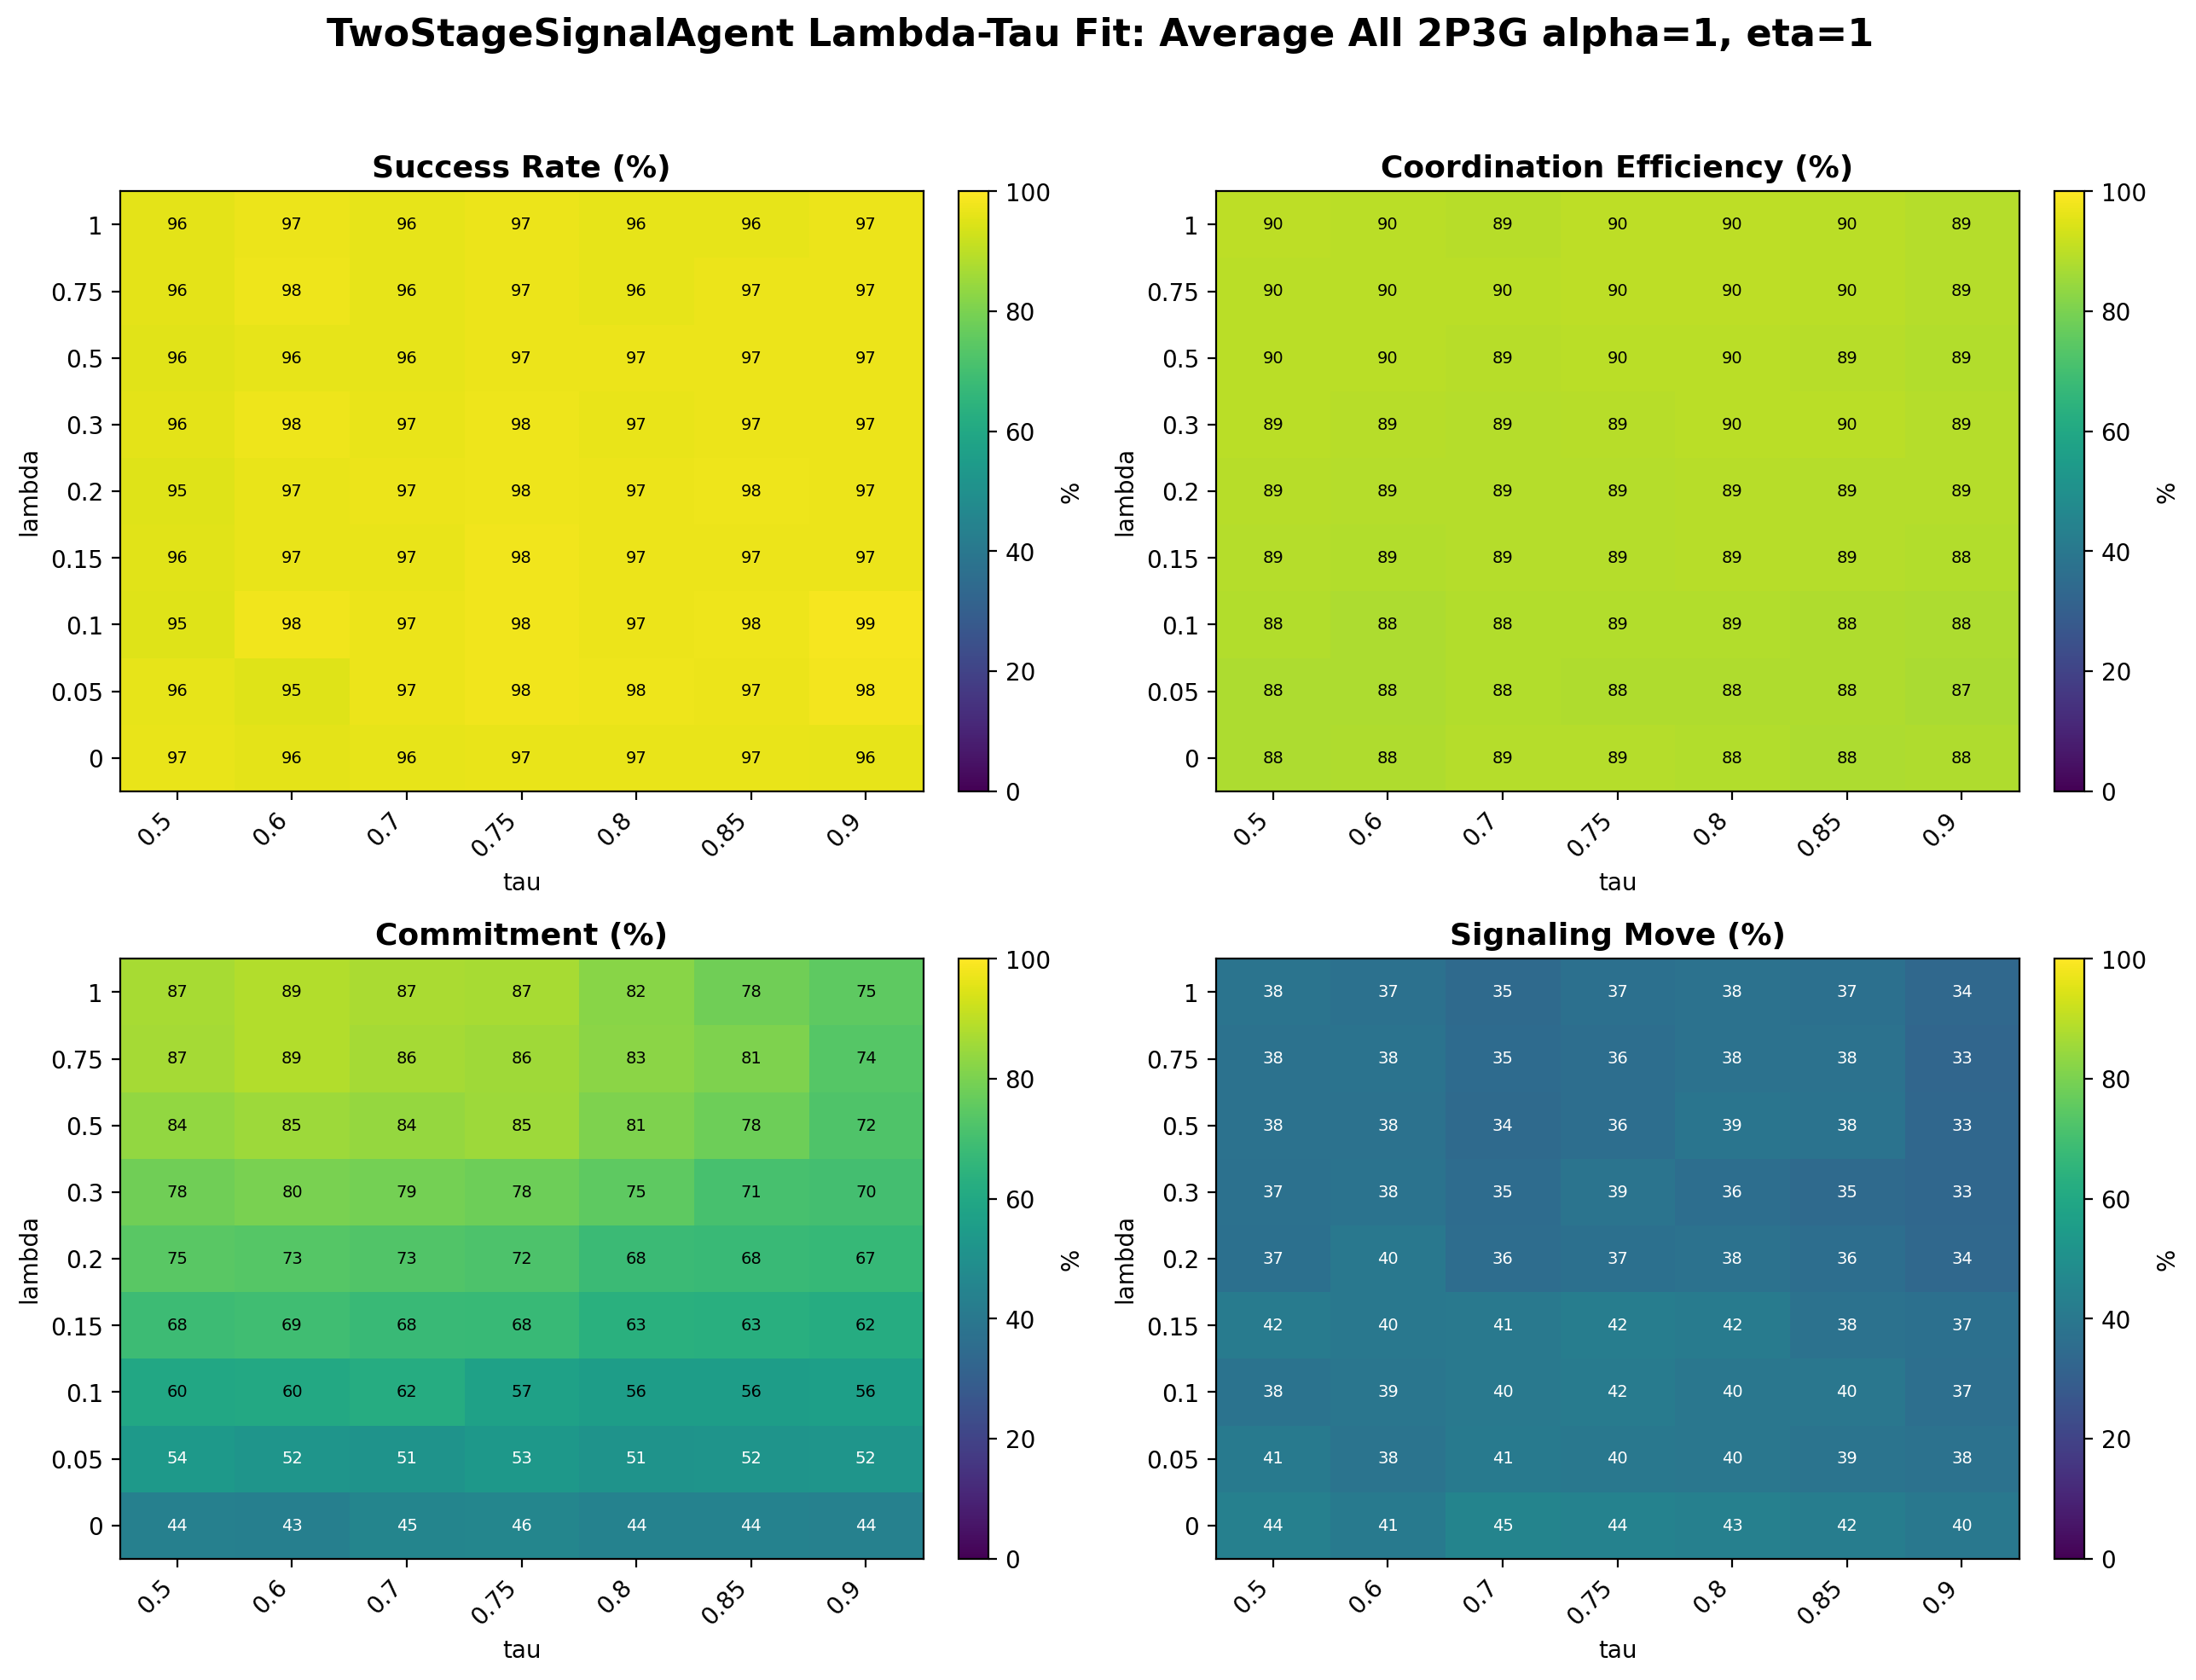

### Equal-to-both only

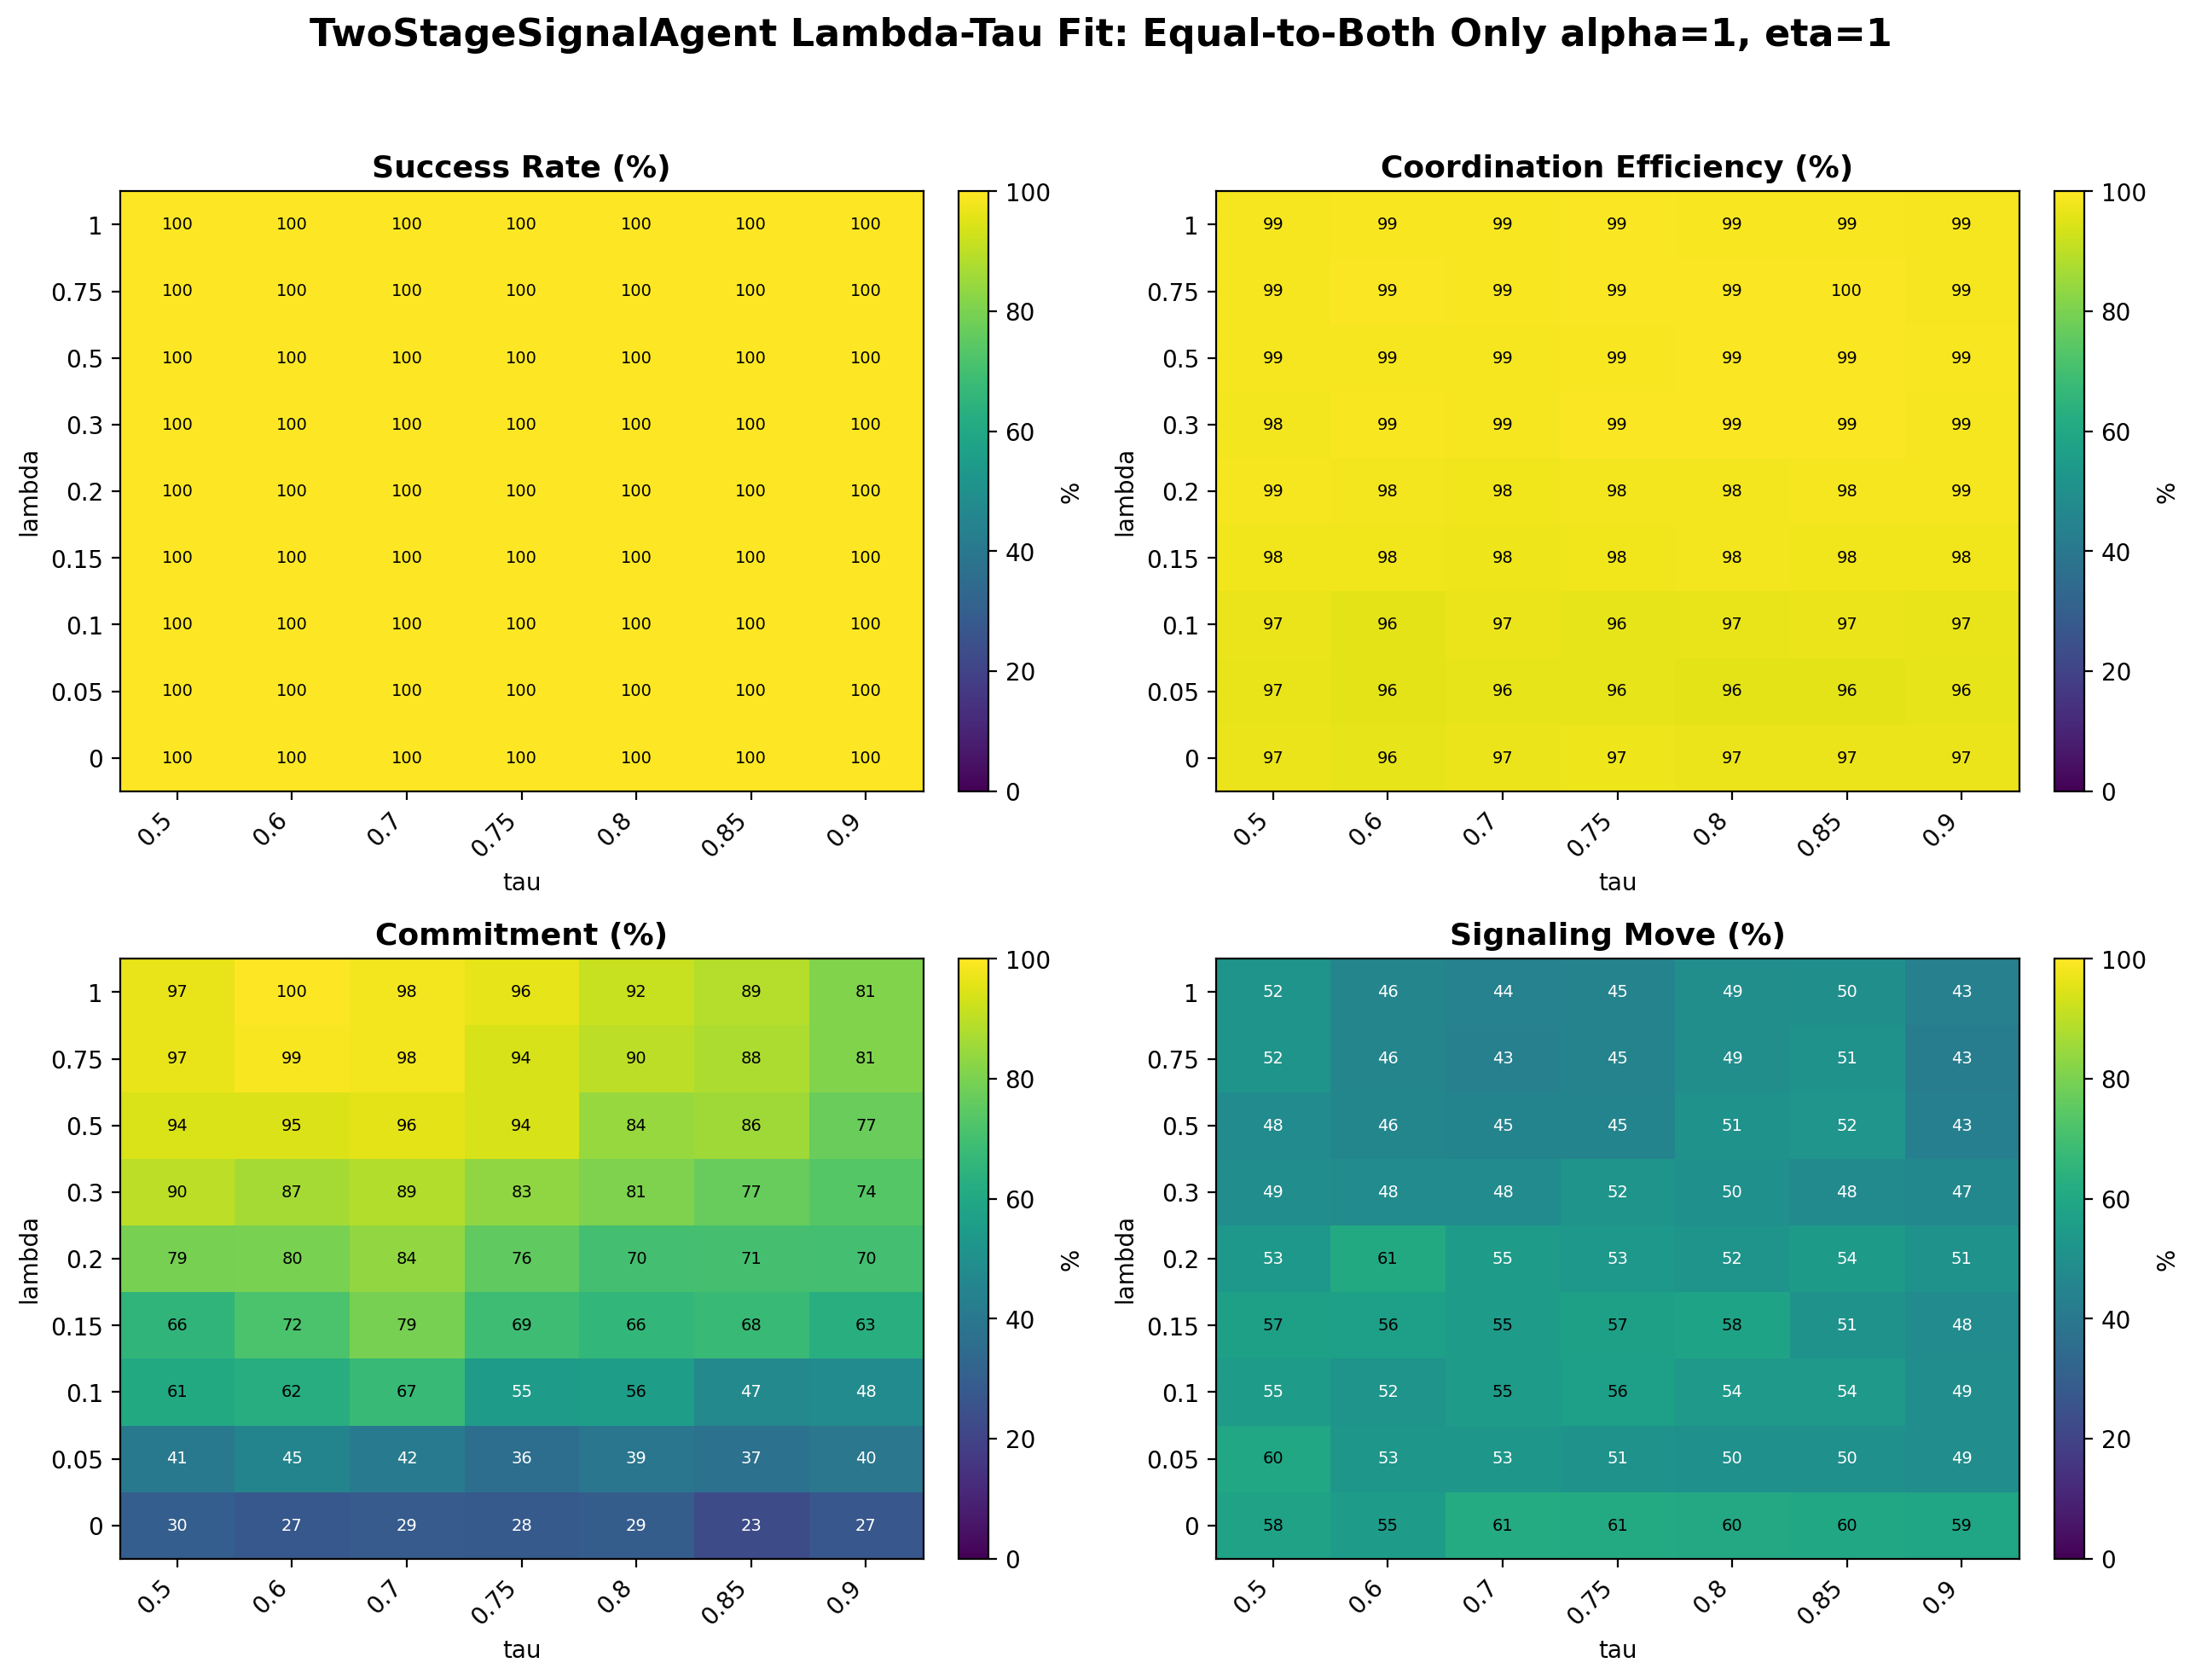

In [4]:
for filename, title in [
    ('two_stage_signal_lambda_tau_average_4measure_heatmaps.png', 'Average across all 2P3G distance conditions'),
    ('two_stage_signal_lambda_tau_equal_to_both_4measure_heatmaps.png', 'Equal-to-both only'),
]:
    path = OUT / filename
    display(Markdown(f'### {title}'))
    display(Image(filename=str(path)))

## Best-Fit Four-Measure Summary

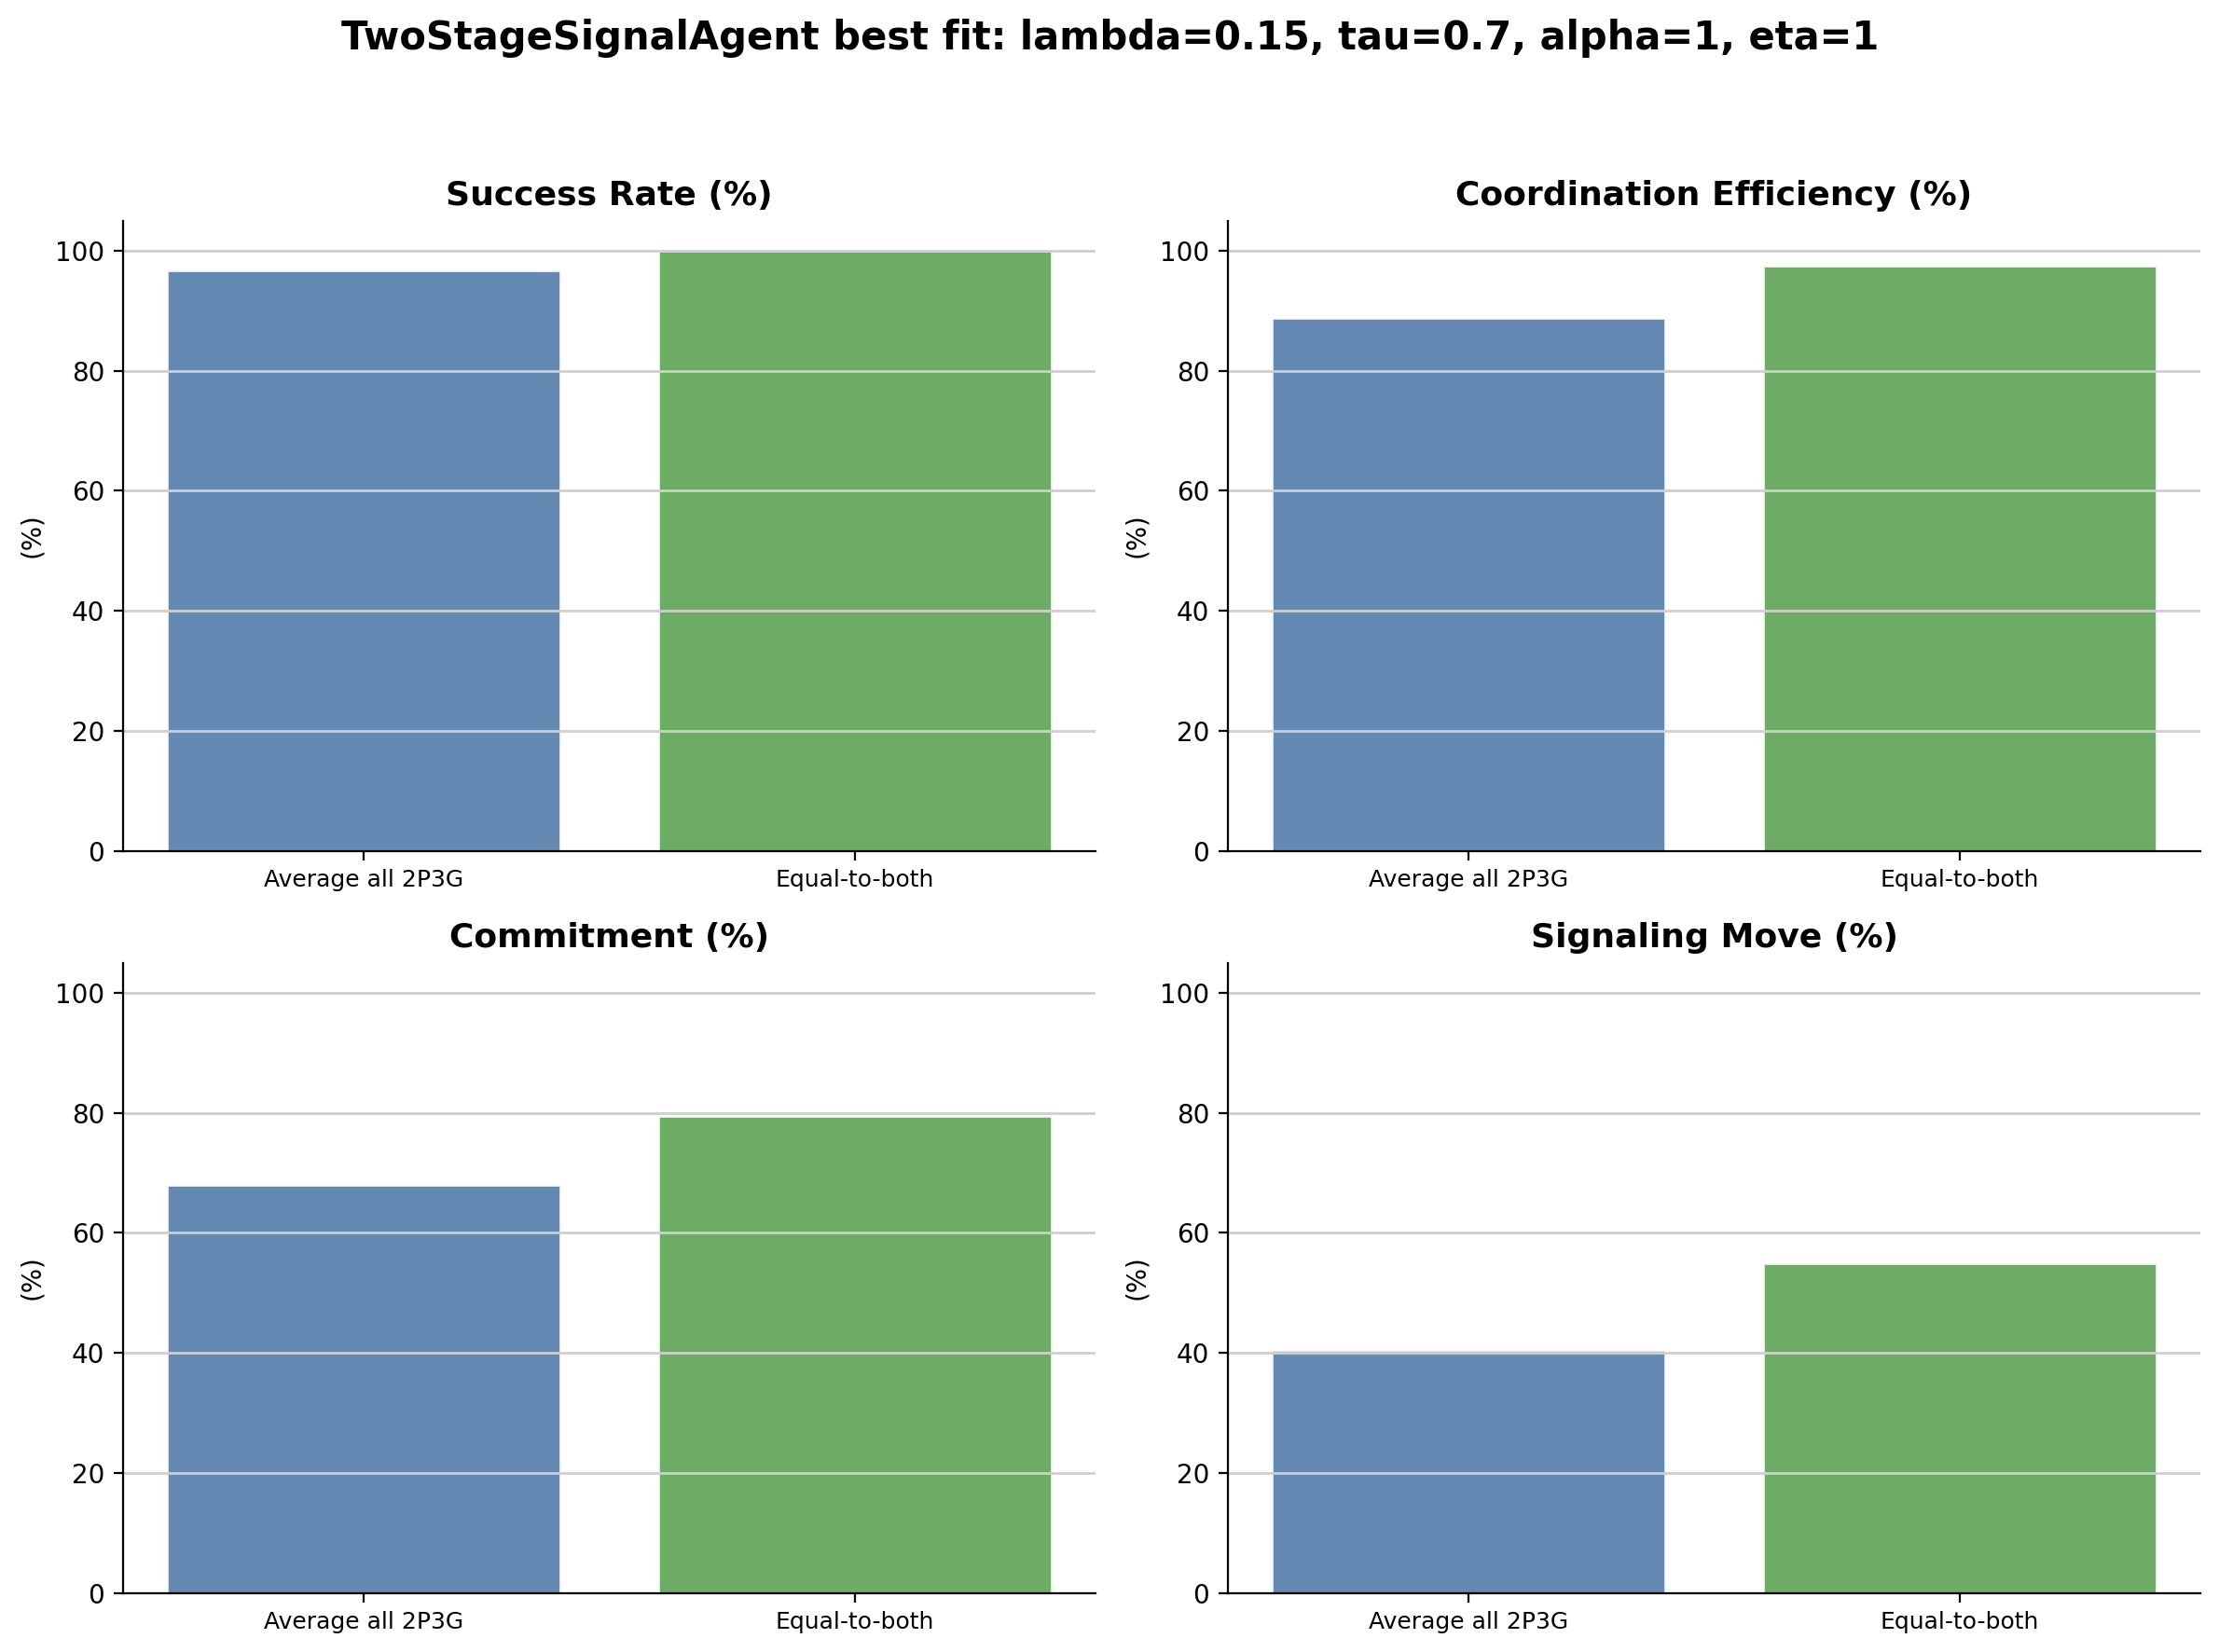

In [5]:
display(Image(filename=str(OUT / 'two_stage_signal_best_average_equal_4panel.png')))

## Best Fit Compared With Human-Human

### Average all 2P3G distance conditions

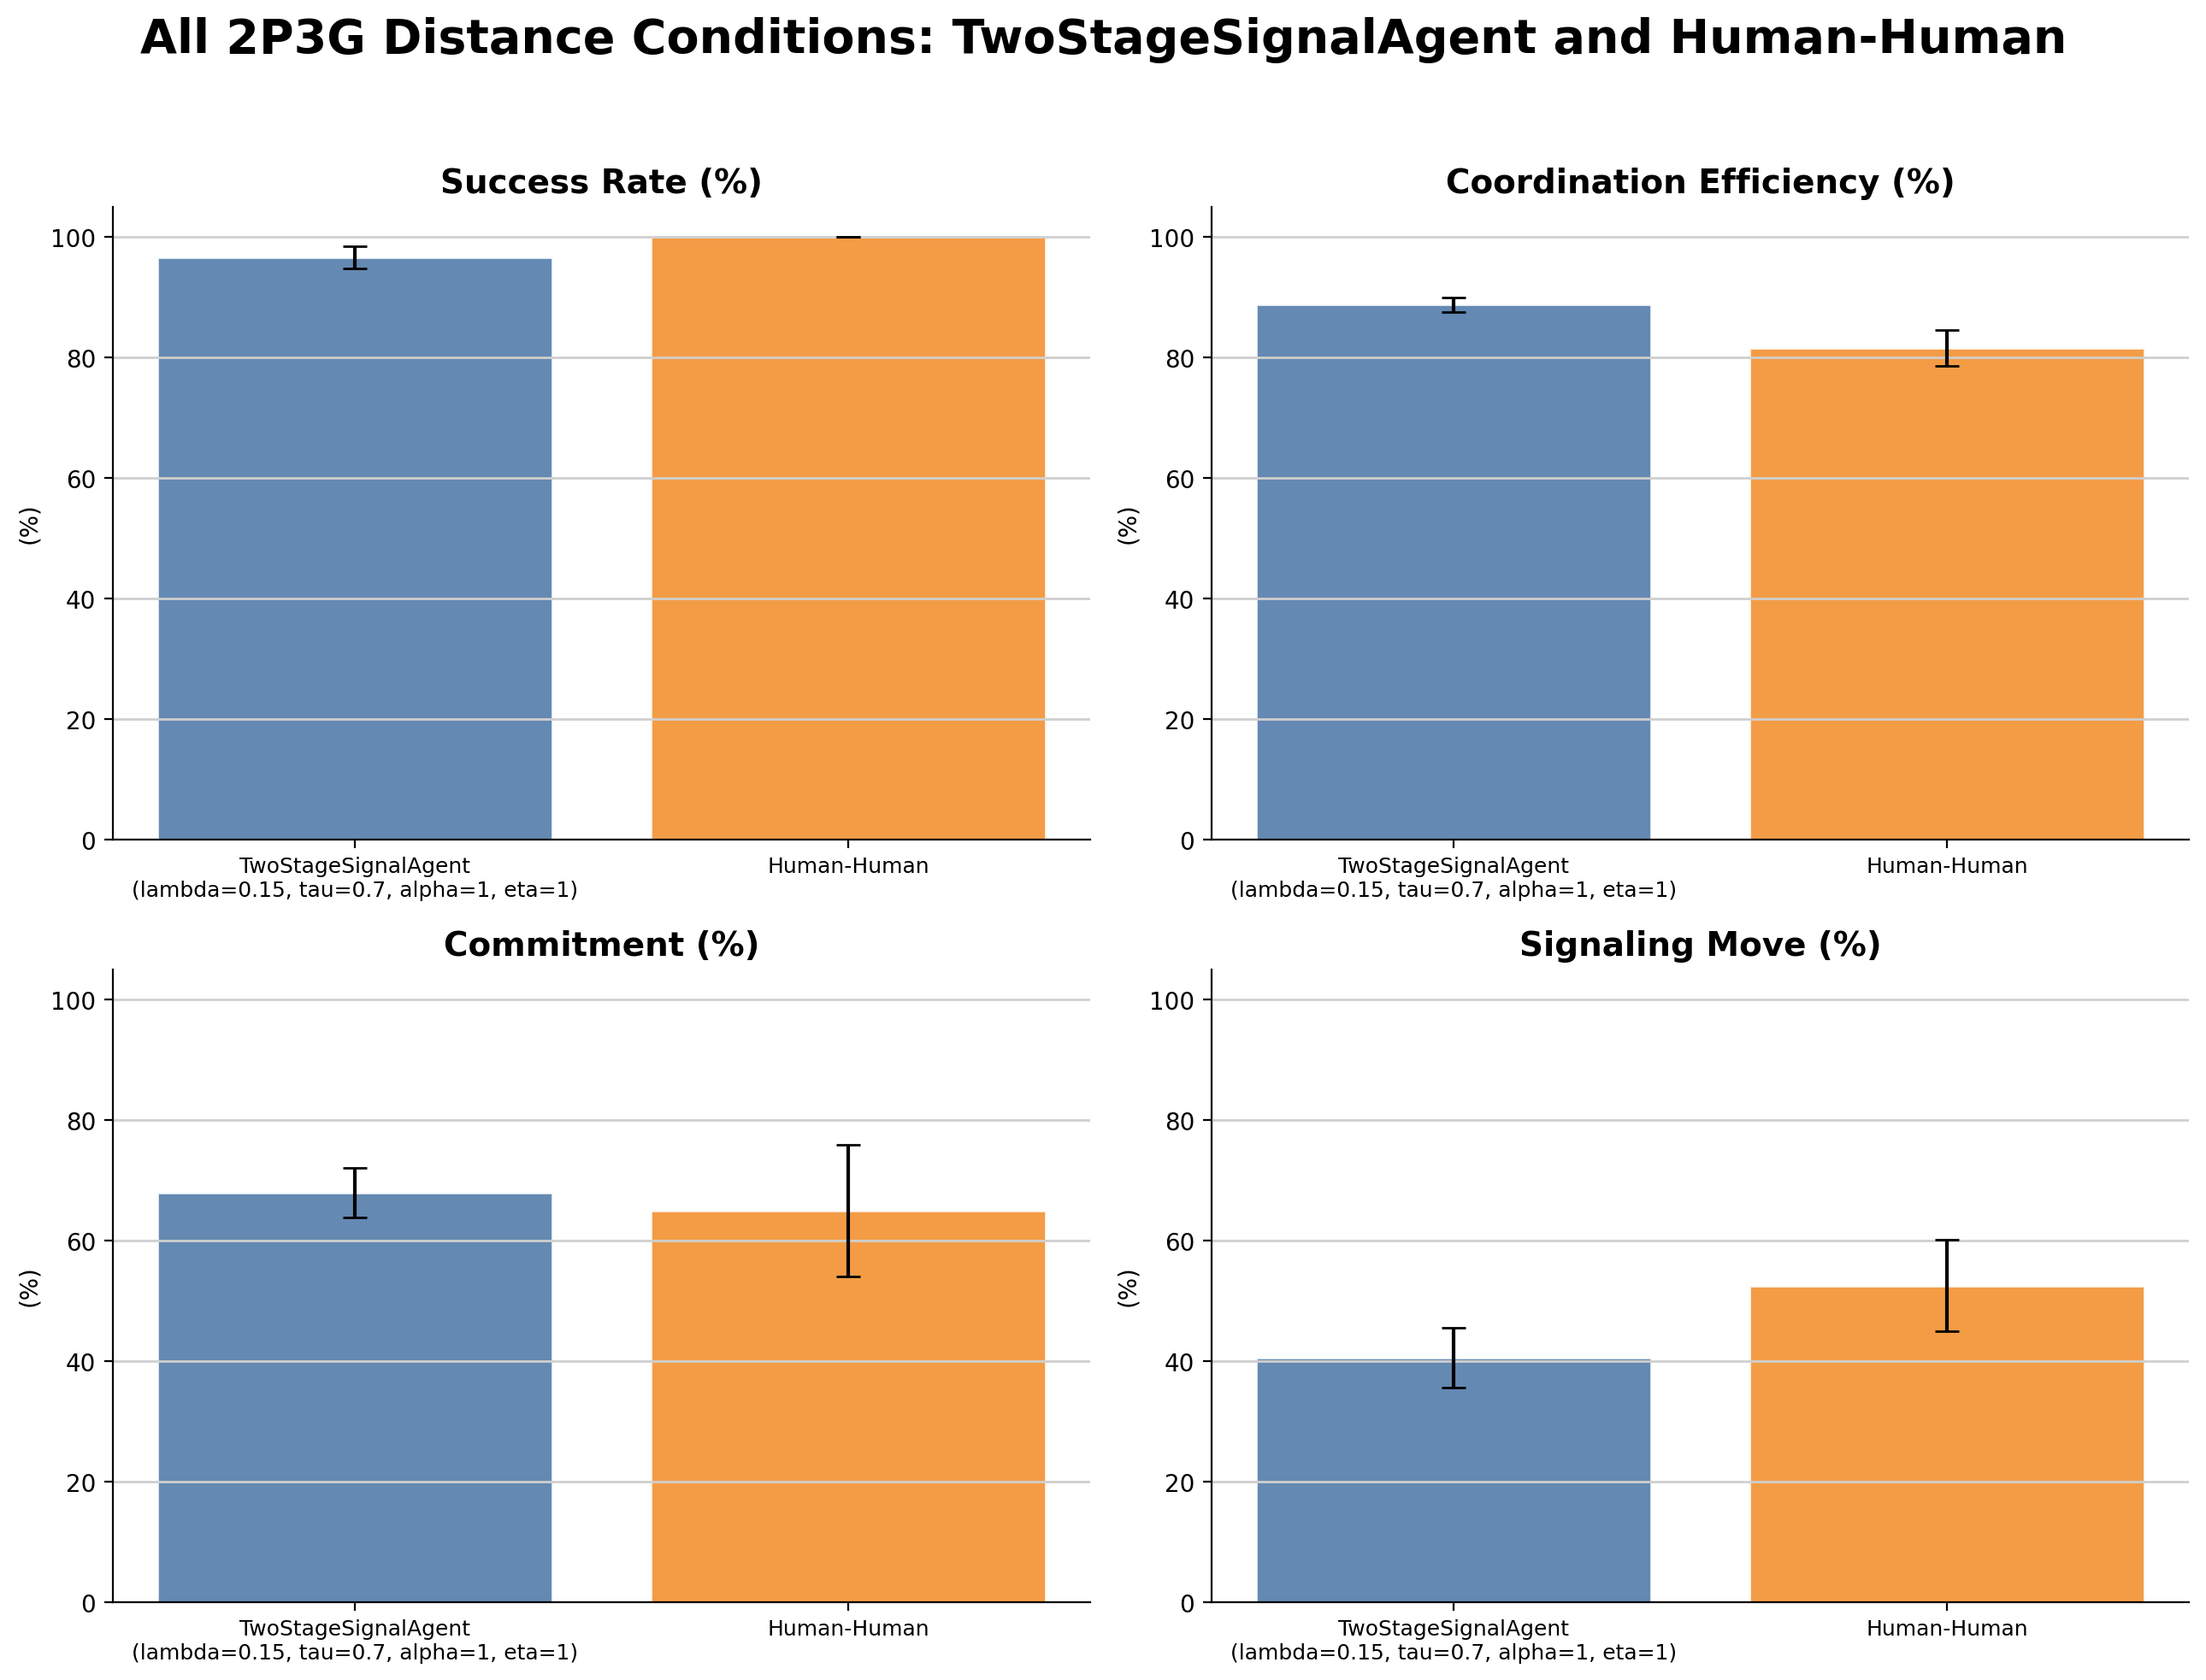

### Equal-to-both only

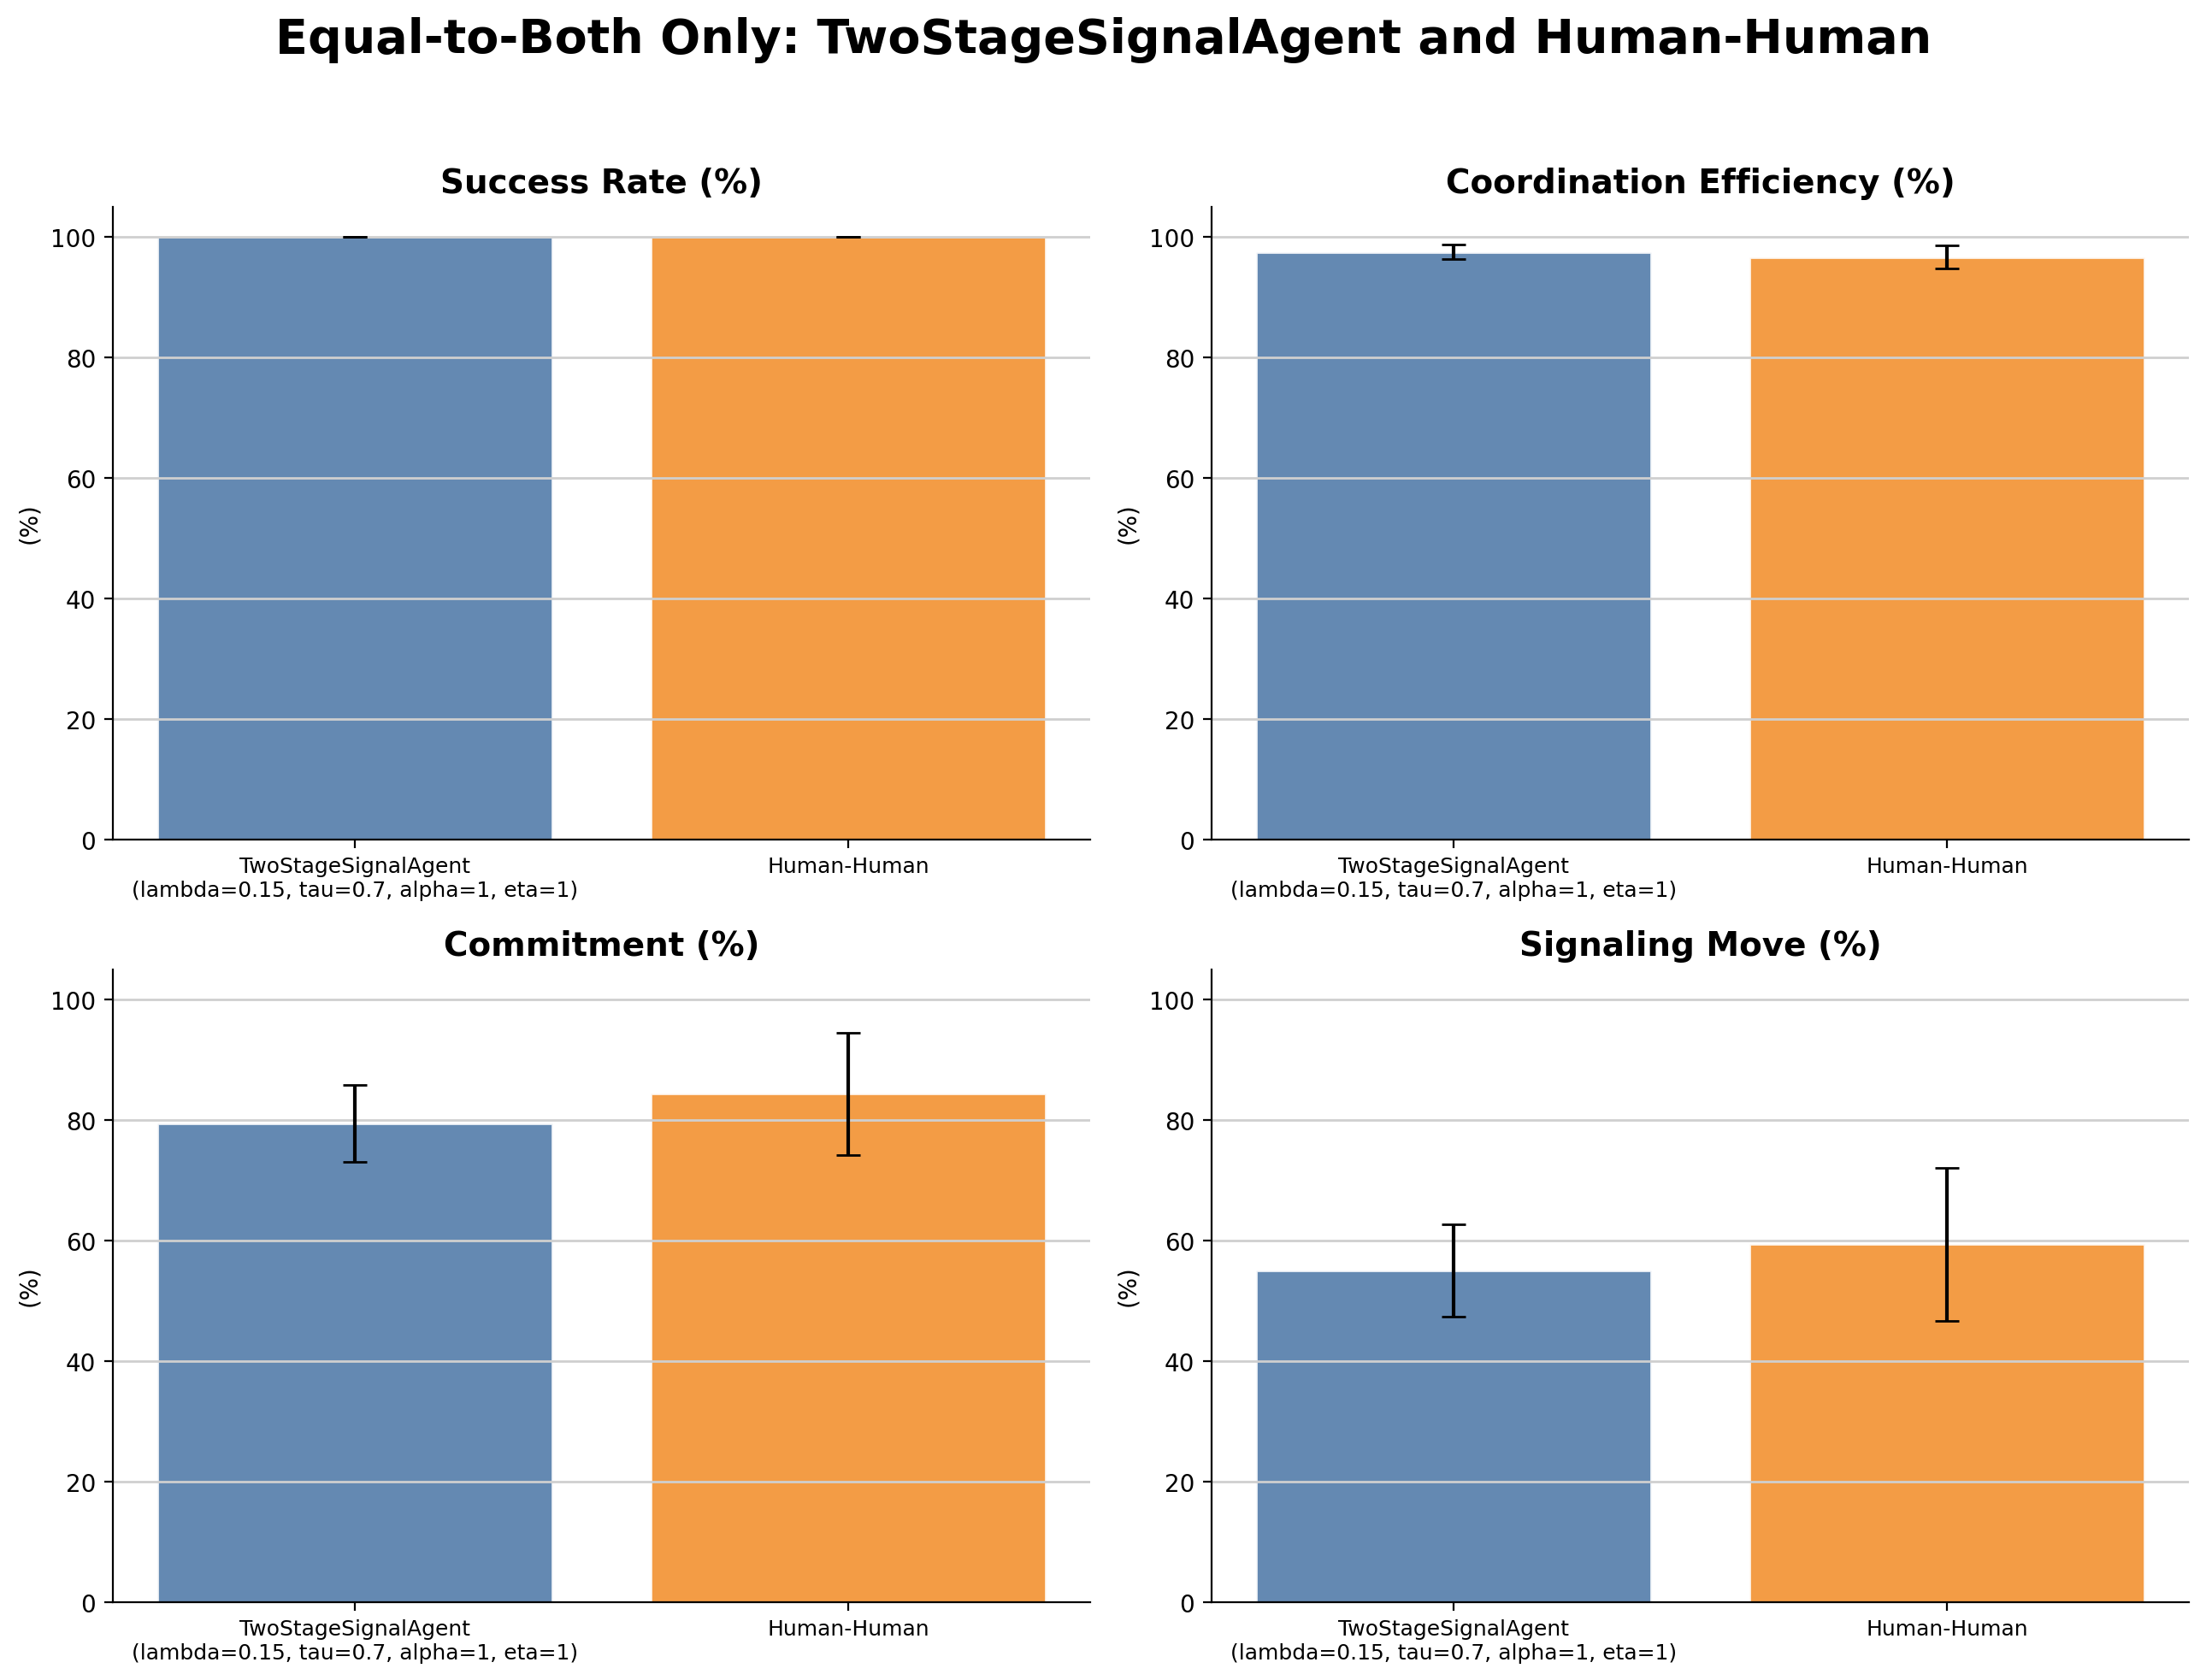

In [6]:
for filename, title in [
    ('two_stage_signal_best_vs_human_4panel_average.png', 'Average all 2P3G distance conditions'),
    ('two_stage_signal_best_vs_human_4panel_equal_to_both.png', 'Equal-to-both only'),
]:
    display(Markdown(f'### {title}'))
    display(Image(filename=str(OUT / filename)))

## Why Commitment Is Not Near 50% at \(\lambda=0\)

In this two-stage model, \(\lambda=0\) only removes the posterior from the goal-weight term:

\[
W_\lambda(g)\propto \exp(\beta EU(g))P_t(g)^\lambda
\]

so:

\[
W_0(g)\propto \exp(\beta EU(g))
\]

But the model is not posterior-free when \(\lambda=0\). Posterior still enters:

1. the confidence gate,

\[
\rho_t=\sigma(k(C_t-\tau)),\quad C_t=\max_gP_t(g)
\]

2. the signaling policy,

\[
\pi_{signal}(a\mid g)\propto \pi_{joint}(a\mid s_t,g)P_t(g\mid a)^\alpha
\]

with \(\alpha=1\), and

3. the trial-final commitment measure, which depends on the final reached goal, not the instantaneous goal weight at new-goal presentation.

Therefore, even if old shared and new goal have equal joint EU at the new-goal moment, the final trajectory can still be pulled toward the new goal over later steps.

,lambda,tau,equal_commitment_percent,equal_signaling_percent,equal_success_percent,equal_efficiency_percent,average_commitment_percent,total_nll
60,0.0,0.50,30.00,57.78,100.0,96.95,43.70,409.13
62,0.0,0.60,27.50,55.28,100.0,96.41,43.18,411.67
56,0.0,0.70,28.89,61.39,100.0,97.15,45.37,405.43
54,0.0,0.75,28.33,61.11,100.0,97.28,45.93,404.46
53,0.0,0.80,29.44,60.28,100.0,97.12,44.30,404.37
58,0.0,0.85,22.99,60.06,100.0,96.92,44.24,406.57
61,0.0,0.90,27.01,58.62,100.0,97.09,43.84,409.38


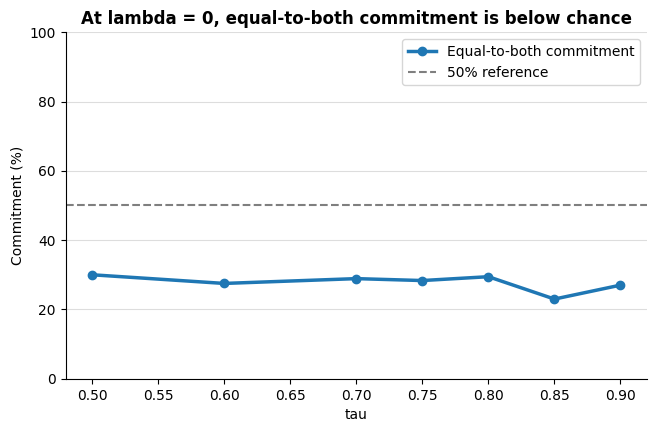

In [7]:
lambda0 = grid[grid['lambda'].eq(0)].sort_values('tau')
cols = [
    'lambda', 'tau', 'equal_commitment_percent', 'equal_signaling_percent',
    'equal_success_percent', 'equal_efficiency_percent', 'average_commitment_percent', 'total_nll'
]
display(lambda0[cols].round(2))

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(lambda0['tau'], lambda0['equal_commitment_percent'], marker='o', linewidth=2.5, label='Equal-to-both commitment')
ax.axhline(50, color='black', linestyle='--', alpha=0.5, label='50% reference')
ax.set_xlabel('tau')
ax.set_ylabel('Commitment (%)')
ax.set_title('At lambda = 0, equal-to-both commitment is below chance', fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(axis='y', color='#dddddd')
ax.legend(frameon=True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.show()

## Lambda-0 Outcome Decomposition

For \(\lambda=0\), the equal-to-both condition mostly ends at the new goal rather than the old shared goal. The table below decomposes final reached goals for representative \(\tau\) values.

outcome,new_goal,old_shared
tau,,
0.50,104,40
0.75,106,40
0.80,106,42


outcome,new_goal,old_shared
tau,,
0.50,72.2,27.8
0.75,72.6,27.4
0.80,71.6,28.4


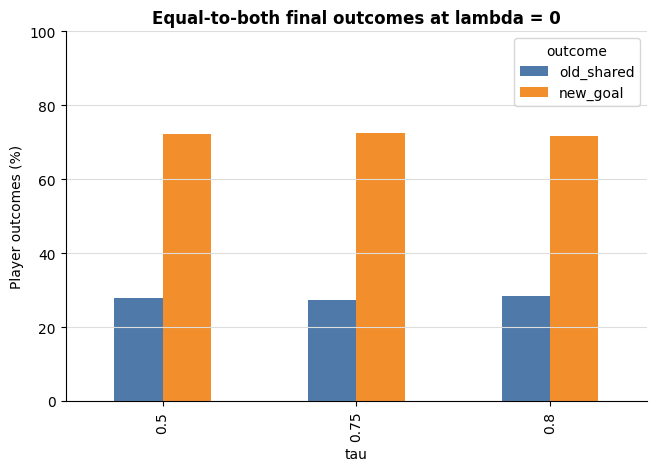

In [8]:
def raw_file(lambda_value, tau, alpha=1, eta=1):
    def fmt(value):
        return f'{value:g}'.replace('-', 'neg').replace('.', 'p')
    return RAW / (
        'two_stage_signal_vs_two_stage_signal_2p3g_raw_trials_'
        f'beta_3_lambda_{fmt(lambda_value)}_tau_{fmt(tau)}_alpha_{fmt(alpha)}_eta_{fmt(eta)}_sessions_0_to_29.json'
    )

def outcome_counts(lambda_value=0, tau=0.75):
    path = raw_file(lambda_value, tau)
    rows = json.loads(path.read_text())
    out = []
    for row in rows:
        if row.get('distanceCondition') != 'equal_to_both' or not row.get('newGoalPresented'):
            continue
        shared = row.get('firstDetectedSharedGoal')
        for player in [1, 2]:
            final = row.get(f'player{player}FinalReachedGoal')
            if final == shared:
                label = 'old_shared'
            elif final == 2:
                label = 'new_goal'
            elif final in [0, 1] and final != shared:
                label = 'other_old'
            else:
                label = str(final)
            out.append({'tau': tau, 'outcome': label})
    return pd.DataFrame(out)

counts = pd.concat([outcome_counts(0, tau) for tau in [0.5, 0.75, 0.8]], ignore_index=True)
summary_counts = counts.groupby(['tau', 'outcome']).size().reset_index(name='n')
summary_counts['percent'] = summary_counts.groupby('tau')['n'].transform(lambda s: 100 * s / s.sum())
display(summary_counts.pivot(index='tau', columns='outcome', values='n').fillna(0).astype(int))
display(summary_counts.pivot(index='tau', columns='outcome', values='percent').fillna(0).round(1))

pivot = summary_counts.pivot(index='tau', columns='outcome', values='percent').fillna(0)
ax = pivot[['old_shared', 'new_goal']].plot(kind='bar', figsize=(7.5, 4.8), color=['#4f79a8', '#f28e2b'])
ax.set_title('Equal-to-both final outcomes at lambda = 0', fontweight='bold')
ax.set_xlabel('tau')
ax.set_ylabel('Player outcomes (%)')
ax.set_ylim(0, 100)
ax.grid(axis='y', color='#dddddd')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.show()

## Sigmoid Gate Intuition

The fitted threshold controls where the model transitions from flexible joint-RL to committed signaling. The figure below shows how changing \(\tau\) shifts the midpoint, while changing \(k\) changes transition sharpness.

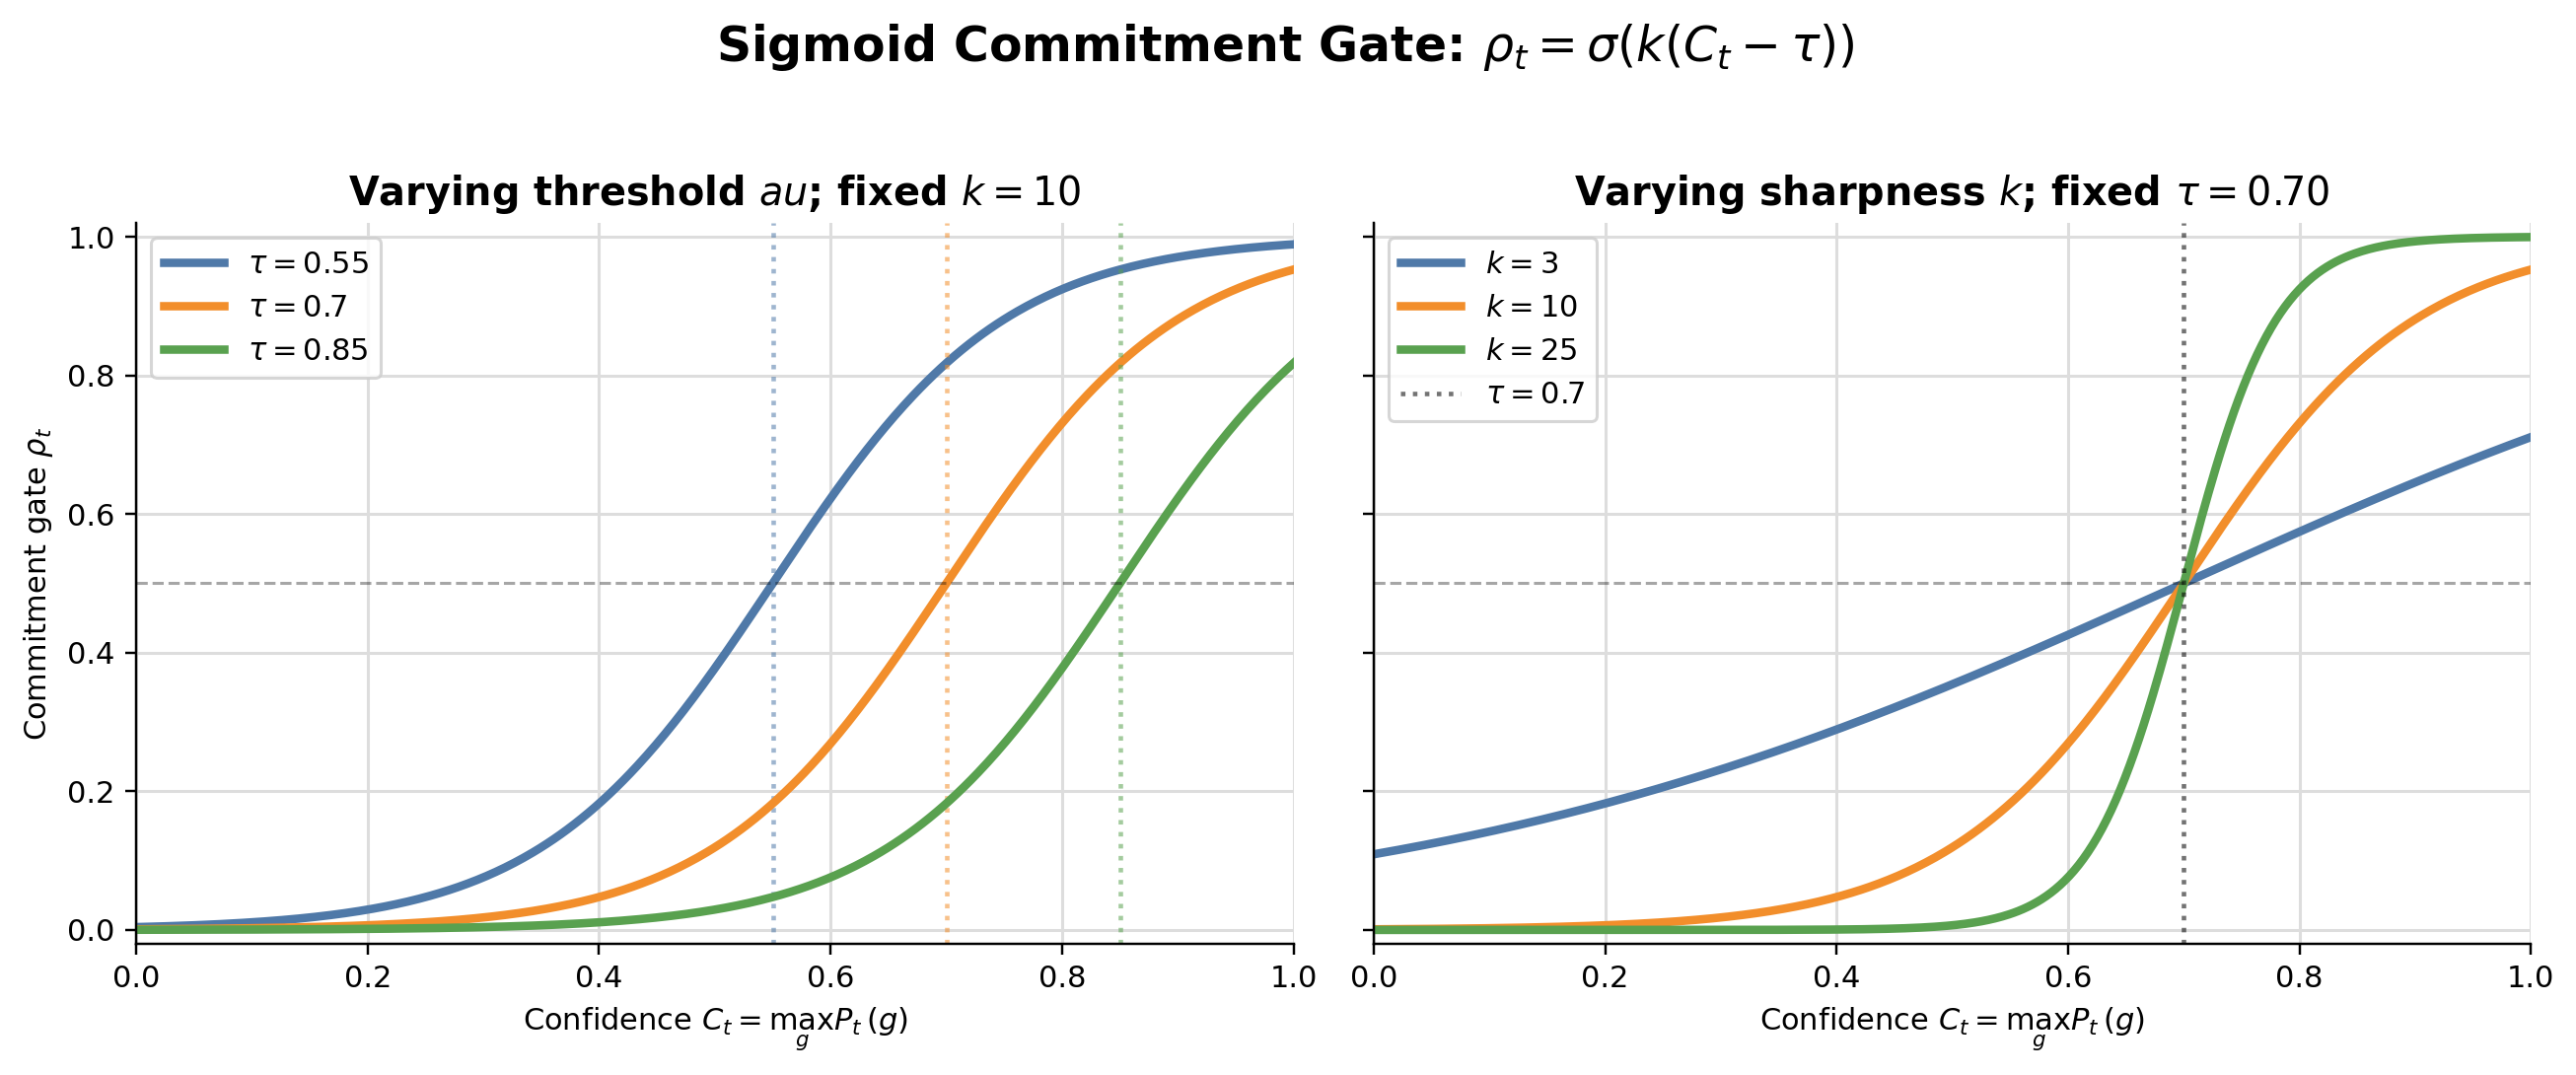

In [9]:
display(Image(filename=str(PROJECT_ROOT / 'docs' / 'SignalAgent' / 'sigmoid_gate_examples.png')))

## Takeaway

The simplified two-stage model is a useful compromise: it has only two fit parameters, \(\lambda\) and \(\tau\), but still captures a graded transition from flexible coordination to committed signaling.

The important caveat is that \(\lambda=0\) is not equivalent to random old-vs-new goal selection. In this model, posterior still affects the gate and the signaling action policy, and the commitment metric is based on the final reached goal.